## Qiskit -- Problem Set 5. Grover's Algorithm
Cristobal Lillo

In [6]:
import qiskit
from qiskit import *
import qiskit_ibm_runtime
import qiskit_aer

# 1: Oracle for Search

> nqubits = 3, 

> $a = 5 = 101_2$

Part a: show that you get the expected result from the quantum circuit for U_f
$$
U_f |y\rangle_1 |x\rangle_3 = X_1 (C^3X)_{0123} X_1|y\rangle|x_2\rangle|x_1\rangle|x_0\rangle \qquad
x_0, x_1, x_2, y ∈ {0, 1} \\
$$
Reducing: 

$$

= X_1 (C^3X)_{0123}|y\rangle|x_2\rangle|\tilde{x_1}\rangle|x_0\rangle \\
= X_1 |y \oplus x_2\tilde{x_1}x_0\rangle|x_2\rangle|\tilde{x_1}\rangle|x_0\rangle \\
=|y \oplus x_2\tilde{x_1}x_0\rangle|x_2\rangle|x_1\rangle|x_0\rangle \\

$$ 

so if x = a (101): 

$$
x_0 = 1 \\
\tilde{x_1} = 1 \\
x_2 = 1 \\
$$

and y goes to $\tilde{y}$ if and only if x = a. So $U_f$ behaves as expected. 


In [7]:


n = 3
a = 5

q=QuantumRegister(n + 1) 
x_c=ClassicalRegister(n, "x")
y_c = ClassicalRegister(1, "y")


oracle = QuantumCircuit(q,x_c,y_c)



In [8]:
def U_f(qc : QuantumCircuit, q : QuantumRegister):
    
    
    qc.x(q[1])
    qc.mcx([q[0],q[1],q[2]], q[3])
    qc.x(q[1])
    
    qc.barrier()



In [9]:

# state preparation -- you can mess with different X gates here to prepare different states. 
# The point is that when you prepare 101, y gets sent to y NOT, and for all other states,
# y is constant.

# oracle.x(q[0])
# oracle.x(q[2])

oracle.barrier()
U_f(oracle, q)
# measure ancillary qubit just to check.
oracle.measure(q[-1], y_c[0])
# this should always measure x.
oracle.measure(q[:-1], x_c)


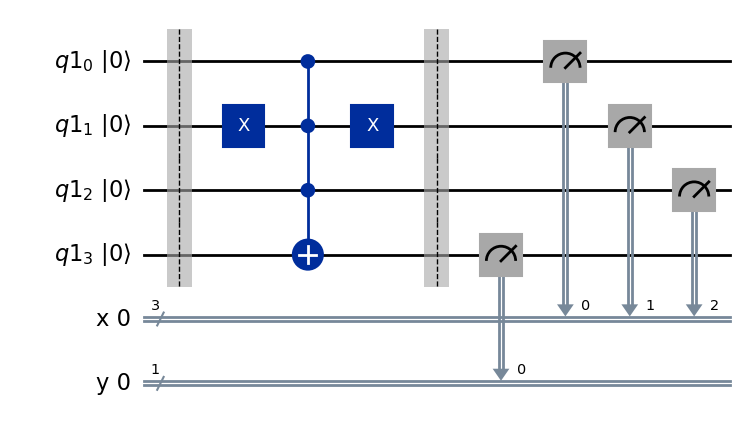

In [10]:
oracle.draw(initial_state=True, output="mpl")

In [11]:
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

In [12]:
backend = AerSimulator()
sampler = AerSampler()

In [13]:
# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
oracle_isa = pm.run(oracle)

In [14]:
job_sim = sampler.run([oracle_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

In [15]:
# Print the DataBin to see what's inside
list(result_sim.data.keys())

key = list(result_sim.data.keys())[0]
print(key)


x


In [16]:
counts_sim = result_sim.data[key].get_counts()
print(counts_sim)

ancilla_measurments =  result_sim.data["y"].get_counts()
print(ancilla_measurments)

{'000': 4096}
{'0': 4096}


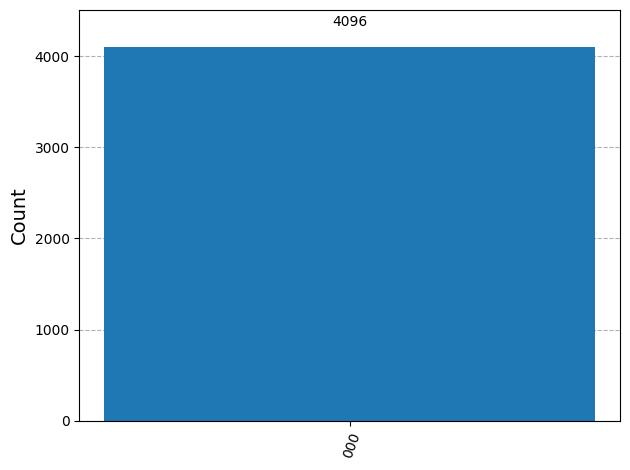

In [17]:
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)

## Question 2: Grover's Algorithm

using $$H_t * C^{X}_{ct} * H_t = Z$$

where c is the n - 1 control qubits,

then $ W = HXH_tC^{X}_{ct}H_tXH$

In [18]:
def W(qc, q):
    for i in range(len(q) - 1):
        qc.h(q[i])
        qc.x(q[i])

    
    qc.barrier()
    qc.h(q[-2])
    qc.mcx(q[:-2], q[-2])
    qc.h(q[-2])
    qc.barrier()
    
    for i in range(len(q) - 1):

        qc.x(q[i])
        qc.h(q[i])

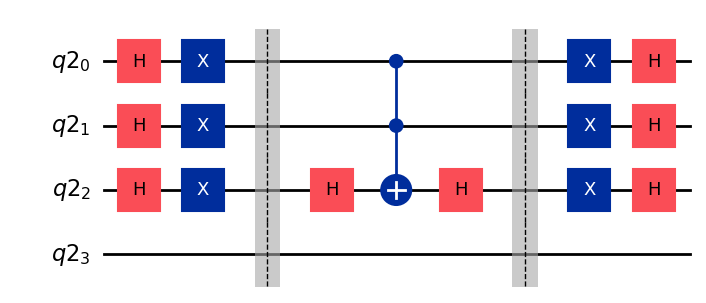

In [19]:
q = QuantumRegister(3 + 1)
qc = QuantumCircuit(q)
W(qc, q)
qc.draw(output="mpl")

## 2b.

Since n = 3,  $$ k = \frac{\pi}{4}\sqrt{2^3} = \frac{\pi}{4}\sqrt{8} \approx 2.22 $$ 

Thus we can use k = 2 for the search




In [20]:
q = QuantumRegister(3 + 1)
c = ClassicalRegister(3)
grover = QuantumCircuit(q, c)

grover.h(q[0])
grover.h(q[1])
grover.h(q[2])

grover.x(q[3])
grover.h(q[3])
grover.barrier()

U_f(grover, q)
grover.barrier()
W(grover, q)

grover.barrier()

U_f(grover, q)
grover.barrier()
W(grover, q)

grover.measure(q[0:3], c)

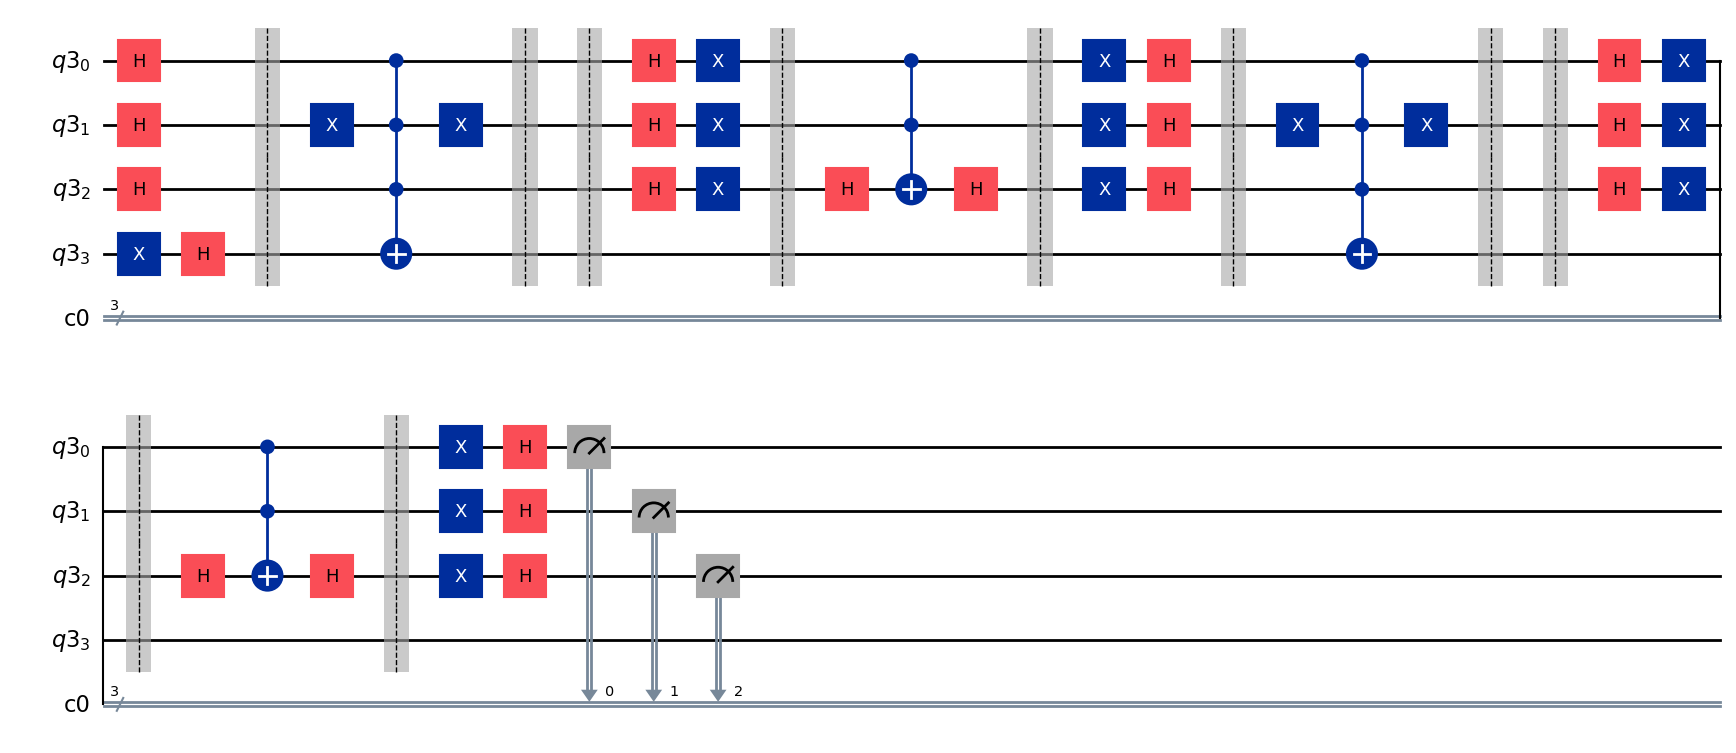

In [21]:
grover.draw(output='mpl')

In [22]:
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

In [23]:
backend = AerSimulator()
sampler = AerSampler()

In [24]:
# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
grover_isa = pm.run(grover)

In [25]:
job_sim = sampler.run([grover_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

In [26]:
# Print the DataBin to see what's inside
print(list(result_sim.data.keys()))


key = list(result_sim.data.keys())[0]


['c0']


In [27]:
counts_sim = result_sim.data[key].get_counts()
print(counts_sim)

{'101': 3860, '111': 34, '011': 33, '001': 37, '100': 35, '110': 31, '010': 31, '000': 35}


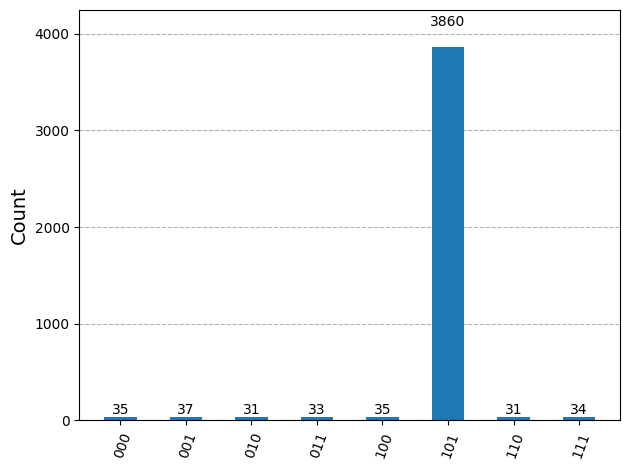

In [28]:
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)

## Remarks on the simulation

As predicted, deutsch's algorithm correctly one shots that U_f is of the 1 type. Though it is likely that the real device does not behave so nicely.

In [29]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Initialize the service
service = QiskitRuntimeService(instance="open-instance")

# Filter for real hardware (not simulators) that is currently operational
backend = service.least_busy(simulator=False, operational=True)
print(f"Running on: {backend.name}")

Running on: ibm_fez


In [30]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_grover = pm.run(grover)

In [31]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
# Initialize the Sampler for your backend
sampler = Sampler(mode=backend)

In [32]:
# Submit the job
job_exp = sampler.run([isa_grover])
job_exp.job_id()

'd70n4ds69uic73cki79g'

In [42]:
job_exp.status()

'RUNNING'

In [44]:
result_exp = job_exp.result()[0]


In [45]:
# Print the DataBin to see what's inside
list(result_exp.data.keys())

['c0']

In [47]:

counts_exp = result_exp.data.c0.get_counts()
print(counts_exp)

{'101': 2560, '011': 206, '001': 220, '000': 179, '111': 300, '110': 185, '100': 228, '010': 218}


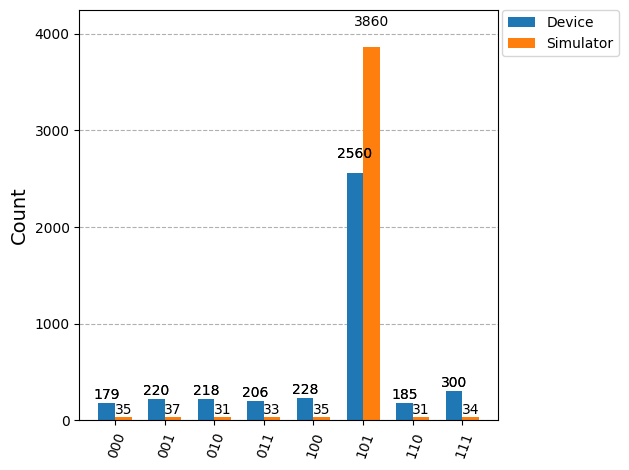

In [48]:
from qiskit.visualization import plot_histogram
plot_histogram([counts_exp,counts_sim], legend=['Device', 'Simulator'])

## Remarks on experimental results

It works! There is significant noise in the measurement of x, but the most probable result is still the correct one, which is 101.

# 3 - Multiple Marked Elements -- Grover's Algorithm for a set S

Firstly, note that $$ k = \frac{\pi}{4} \sqrt{\frac{2^n}{m}} $$
where  $m = \mid S\mid = 3$, yields $$k = \frac{\pi}{4} \sqrt{\frac{2^3}{3}} = \frac{\pi}{4} \sqrt{\frac{8}{3}} \approx 1.28$$

thus we use k = 1, aka we rotate once. 

We can keep W as is, but need to change U_f to work for multiple marked elements.

In [49]:
print(bin(5))

print(bin(2))
print(f"{2:03b}")

0b101
0b10
010


In [50]:
def subU_f(qc, q, a : int):
    # implement the oracle for a single element a of S
    
    # convert to binary with 3 bits, reverse endianness
    e = f"{a:03b}"[::-1]
    print(e)
    
    for i, bit in enumerate(e):
        if bit == '0':
            qc.x(q[i])
            
    qc.mcx([q[0],q[1],q[2]], q[3])


    # double tilde reset
    for i, bit in enumerate(e):
        if bit == '0':
            qc.x(q[i])

    

In [51]:
from typing import Set

# because we are acting on the output qubit, then we can just set 3 consecutive U_f gates for 2, 4, and 6. 

def U_f_multi(qc, q, marked_elements : Set[int]):
    for element in marked_elements:
        qc.barrier()
        subU_f(qc, q, element)

In [52]:
q = QuantumRegister(3 + 1)
c = ClassicalRegister(3)
multigrover = QuantumCircuit(q, c)

multigrover.h(q[0])
multigrover.h(q[1])
multigrover.h(q[2])

multigrover.x(q[3])
multigrover.h(q[3])


U_f_multi(multigrover, q, {2, 4, 6})
multigrover.barrier()
W(multigrover, q)

multigrover.barrier()

multigrover.measure(q[0:3], c)

010
001
011


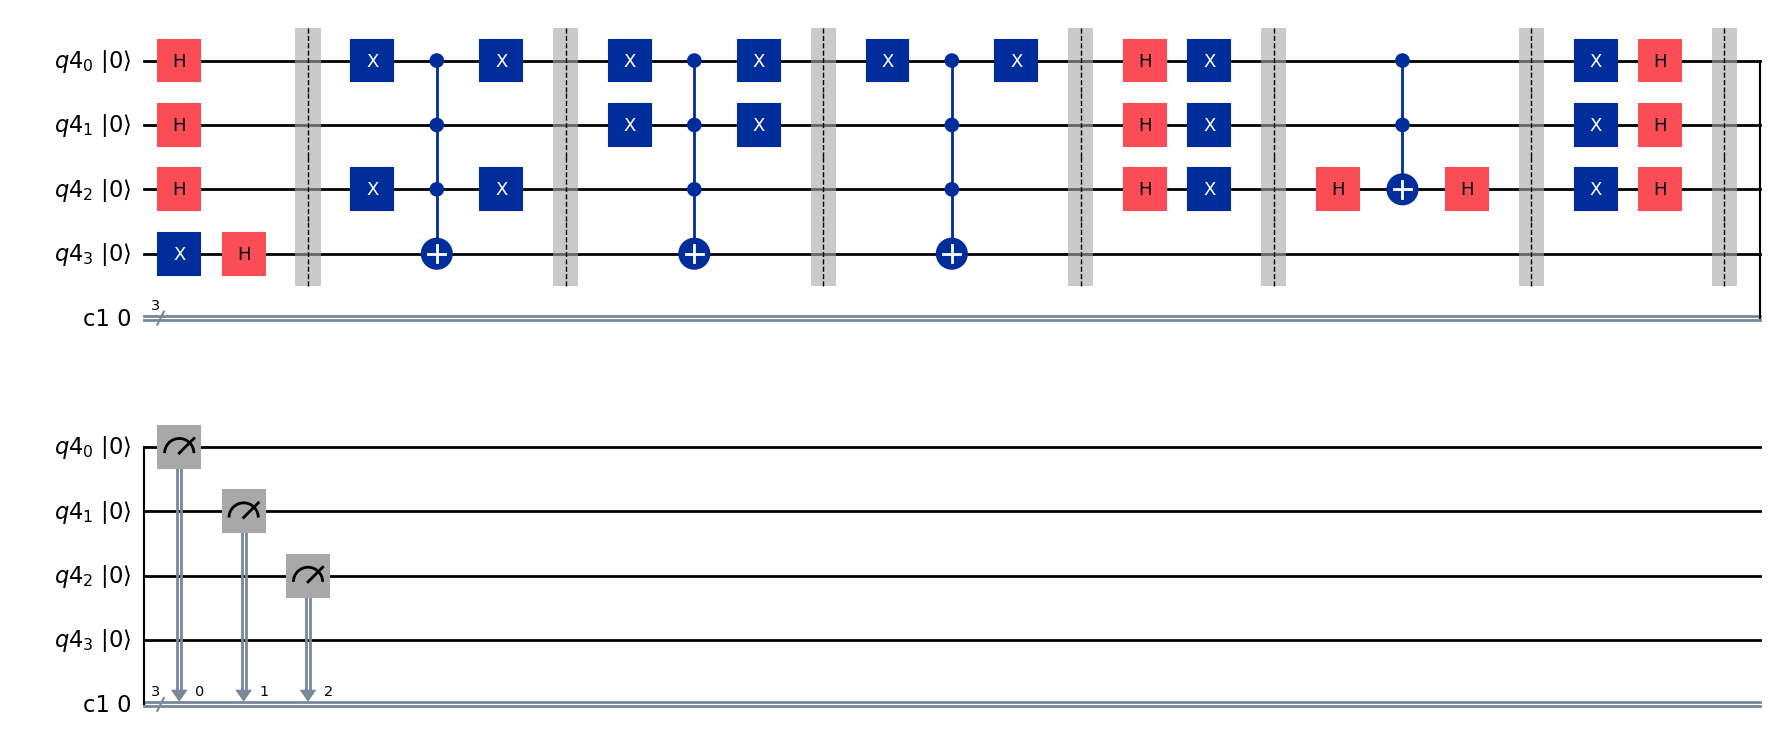

In [53]:
multigrover.draw(initial_state=True, output='mpl')

In [54]:
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

In [55]:
backend = AerSimulator()
sampler = AerSampler()

In [56]:
# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
multigrover_isa = pm.run(multigrover)

In [57]:
job_sim = sampler.run([multigrover_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

In [58]:
# Print the DataBin to see what's inside
list(result_sim.data.keys())

['c1']

In [59]:
counts_sim = result_sim.data.c1.get_counts()
print(counts_sim)

{'010': 1187, '110': 1119, '100': 1150, '000': 123, '001': 126, '101': 133, '011': 138, '111': 120}


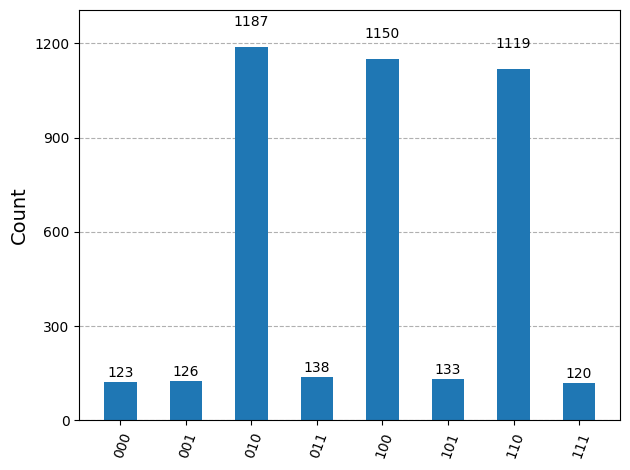

In [60]:
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)

## Remarks :

Simulation results seem to correspond to the set {2, 4, 6} = {010, 100, 110}, works well.

